In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 加载数据（假设数据已保存为data.txt，每行代表一个样本）
data = []
with open('data.txt', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            data.append(list(map(float, line.split())))

data = np.array(data)
X = data[:, :-1]  # 前54列：特征
y = data[:, -1].astype(int)  # 最后1列：标签（1-7）

# 数据基本信息
print("数据形状：", X.shape)
print("标签分布：")
print(pd.Series(y).value_counts().sort_index())
print("特征均值范围：", X.mean(axis=0).min(), "~", X.mean(axis=0).max())
print("特征标准差范围：", X.std(axis=0).min(), "~", X.std(axis=0).max())

数据形状： (406708, 54)
标签分布：
1    148625
2    198031
3     25038
4      1930
5      6651
6     12162
7     14271
Name: count, dtype: int64
特征均值范围： 2.458766486029289e-06 ~ 2959.155743186758
特征标准差范围： 0.001568043507200656 ~ 1557.7371637578244


In [3]:
# 标准化处理
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 验证标准化结果
print("标准化后特征均值范围：", X_scaled.mean(axis=0).min(), "~", X_scaled.mean(axis=0).max())
print("标准化后特征标准差范围：", X_scaled.std(axis=0).min(), "~", X_scaled.std(axis=0).max())

标准化后特征均值范围： -1.1492471695804543e-14 ~ 9.257009711445821e-15
标准化后特征标准差范围： 0.9999999999925903 ~ 1.000000000007389


降维后形状: (406708, 20)
累计方差解释: 0.54


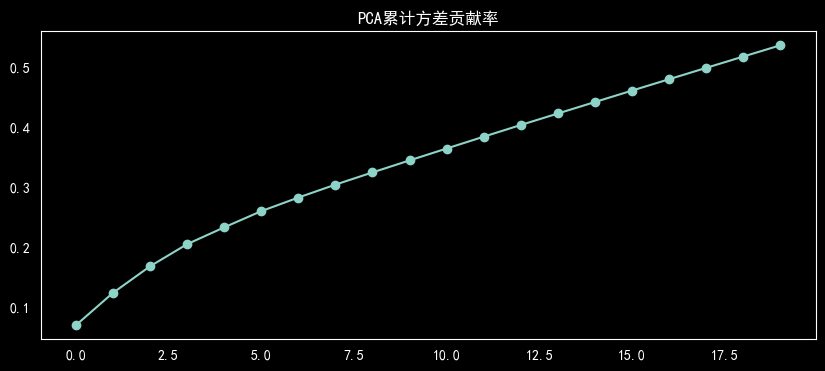

In [4]:
pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"降维后形状: {X_pca.shape}")
print(f"累计方差解释: {pca.explained_variance_ratio_.sum():.2f}")

# 绘图
plt.figure(figsize=(10,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'o-')
plt.title('PCA累计方差贡献率')
plt.grid()
plt.show()

In [5]:
models = {
    "逻辑回归": LogisticRegression(max_iter=1000, random_state=42),
    "随机森林": RandomForestClassifier(n_estimators=50, random_state=42),
    "K近邻": KNeighborsClassifier(n_neighbors=5, weights='distance')
}

===== 十折交叉验证 =====
训练: 逻辑回归
逻辑回归  平均准确率: 0.6963
训练: 随机森林
随机森林  平均准确率: 0.9384
训练: K近邻


  File "D:\conda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "D:\conda\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\conda\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "D:\conda\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


K近邻  平均准确率: 0.9056


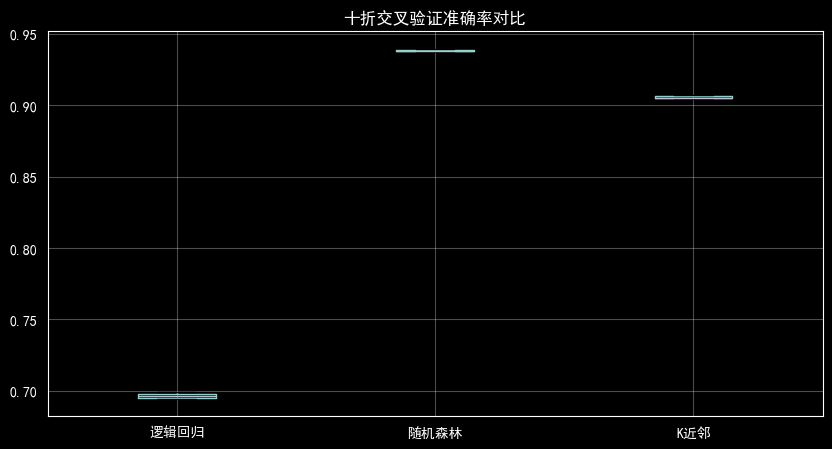

In [6]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = {}

print("===== 十折交叉验证 =====")
for name, model in models.items():
    print(f"训练: {name}")
    acc = cross_val_score(model, X_pca, y, cv=cv, scoring="accuracy", n_jobs=1)
    cv_results[name] = {
        "acc_mean": acc.mean(),
        "acc_std": acc.std(),
        "acc": acc
    }
    print(f"{name}  平均准确率: {acc.mean():.4f}")

# 绘图对比
plt.figure(figsize=(10,5))
pd.DataFrame({k: v["acc"] for k,v in cv_results.items()}).boxplot()
plt.title("十折交叉验证准确率对比")
plt.grid(alpha=0.3)
plt.show()

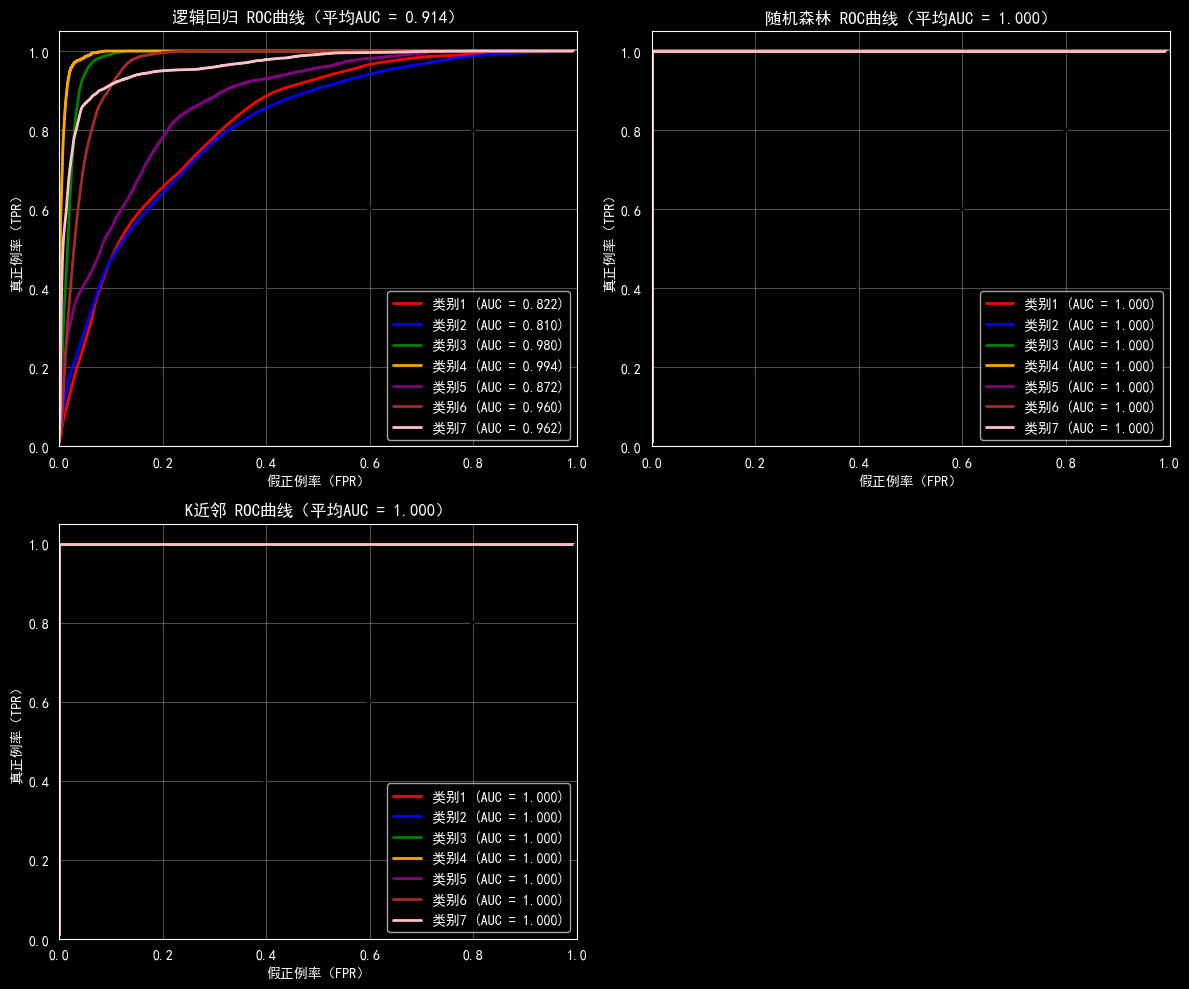


=== 平均AUC对比 ===
逻辑回归: 平均AUC = 0.9142
随机森林: 平均AUC = 1.0000
K近邻: 平均AUC = 1.0000


In [7]:
# 计算多分类AUC并绘制ROC曲线
plt.figure(figsize=(12, 10))

for idx, (name, model) in enumerate(models.items(), 1):
    # One-vs-Rest策略适配多分类
    ovr_model = OneVsRestClassifier(model)
    # 训练并预测概率
    ovr_model.fit(X_pca, y)
    y_score = ovr_model.predict_proba(X_pca)

    # 计算每个类别的ROC和AUC
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    n_classes = len(np.unique(y))

    for i in range(n_classes):
        true_label = (y == (i+1)).astype(int)  # 类别1-7对应索引0-6
        fpr[i], tpr[i], _ = roc_curve(true_label, y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # 计算平均AUC
    mean_auc = np.mean(list(roc_auc.values()))
    cv_results[name]['mean_auc'] = mean_auc

    # 绘制该模型的ROC曲线
    plt.subplot(2, 2, idx)
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'类别{i+1} (AUC = {roc_auc[i]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('假正例率（FPR）')
    plt.ylabel('真正例率（TPR）')
    plt.title(f'{name} ROC曲线（平均AUC = {mean_auc:.3f}）')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 输出平均AUC对比
print("\n=== 平均AUC对比 ===")
for name, res in cv_results.items():
    print(f"{name}: 平均AUC = {res['mean_auc']:.4f}")


=== K近邻 详细分类报告 ===
              precision    recall  f1-score   support

         类别1       1.00      1.00      1.00    148625
         类别2       1.00      1.00      1.00    198031
         类别3       1.00      1.00      1.00     25038
         类别4       1.00      1.00      1.00      1930
         类别5       1.00      1.00      1.00      6651
         类别6       1.00      1.00      1.00     12162
         类别7       1.00      1.00      1.00     14271

    accuracy                           1.00    406708
   macro avg       1.00      1.00      1.00    406708
weighted avg       1.00      1.00      1.00    406708



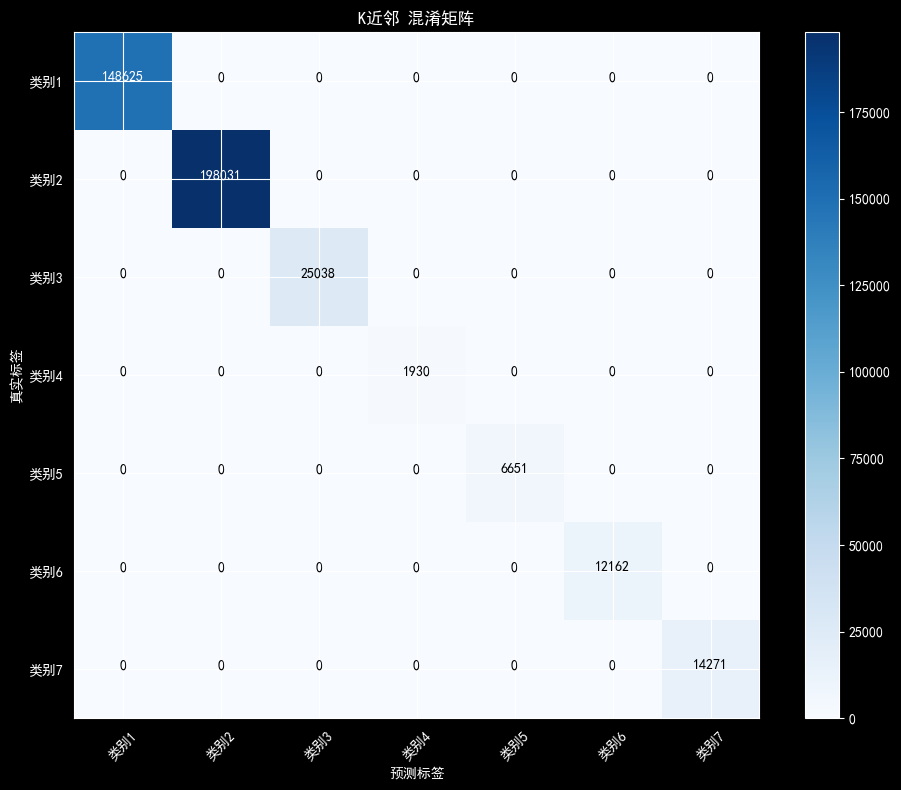

In [8]:
# 选择平均AUC最高的模型进行详细分析
best_model_name = max(cv_results.keys(), key=lambda x: cv_results[x]['mean_auc'])
best_model = models[best_model_name]

# 全量数据训练最优模型
best_model.fit(X_pca, y)
y_pred = best_model.predict(X_pca)

# 输出分类报告
print(f"\n=== {best_model_name} 详细分类报告 ===")
print(classification_report(y, y_pred, target_names=[f'类别{i}' for i in range(1, 8)]))

# 绘制混淆矩阵
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'{best_model_name} 混淆矩阵')
plt.colorbar()
tick_marks = np.arange(7)
plt.xticks(tick_marks, [f'类别{i}' for i in range(1, 8)], rotation=45)
plt.yticks(tick_marks, [f'类别{i}' for i in range(1, 8)])

# 在混淆矩阵中添加数值
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('真实标签')
plt.xlabel('预测标签')
plt.tight_layout()
plt.show()